In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
raw_df = pd.read_html("player_data.html", flavor="bs4")[0]


In [4]:
df = raw_df.copy()

In [5]:
df.describe()

,WP Pts,WR,Vers,Temp,Spor,Prof,Pres,PA,Loy,Inj Pr,...,Com,Cmd,Bra,Bal,Ant,Agi,Agg,Acc,Age,Ada
count,0.0,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,...,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000,43852.000000
mean,NaN,1941.712944,10.849289,13.179923,11.212944,11.848080,11.133609,106.529964,11.331342,8.401145,...,2.795312,2.846620,9.494938,9.473889,9.331661,10.840281,10.432911,11.039953,22.549667,12.127155
std,NaN,1554.150134,3.061273,3.582345,2.534312,2.288719,2.279396,25.294223,2.343715,3.275575,...,2.422184,2.537967,3.558660,3.051836,2.901876,2.444174,3.126179,2.656439,6.193325,3.920462
min,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.000000,1.000000
25%,NaN,839.000000,9.000000,11.000000,10.000000,10.000000,10.000000,91.000000,10.000000,6.000000,...,1.000000,1.000000,7.000000,7.000000,7.000000,9.000000,8.000000,9.000000,17.000000,9.000000
50%,NaN,1471.000000,11.000000,13.000000,11.000000,12.000000,11.000000,107.000000,11.000000,8.000000,...,2.000000,2.000000,9.000000,10.000000,10.000000,11.000000,11.000000,11.000000,21.000000,12.000000
75%,NaN,2731.250000,13.000000,16.000000,13.000000,13.000000,12.000000,124.000000,13.000000,11.000000,...,3.000000,3.000000,12.000000,12.000000,12.000000,13.000000,13.000000,13.000000,27.000000,15.000000
max,NaN,9428.000000,20.000000,20.000000,20.000000,20.000000,20.000000,200.000000,20.000000,20.000000,...,19.000000,17.000000,20.000000,19.000000,20.000000,20.000000,20.000000,20.000000,56.000000,20.000000


In [6]:
df.columns

Index(['Inf', 'Rec', 'Name', 'WP Pts', 'WR', 'Vers', 'Temp', 'Spor', 'Prof',
       'Pres', 'PA', 'Loy', 'Newgen', 'Inj Pr', 'Imp M', 'HR', 'Dirt', 'CR',
       'CA', 'Cont', 'Cons', 'AP', 'Amb', 'Vis', 'Wor', 'Aer', 'Thr', 'Tec',
       'Tea', 'Tck', 'Str', 'Sta', 'TRO', 'Ref', 'Pun', 'Pos', 'Pen', 'Pas',
       'Pac', '1v1', 'OtB', 'Nat', 'Mar', 'L Th', 'Lon', 'Ldr', 'Kic', 'Jum',
       'Hea', 'Han', 'Fre', 'Fla', 'Fir', 'Fin', 'Ecc', 'Dri', 'Det', 'Dec',
       'Cro', 'Cor', 'Cnt', 'Cmp', 'Com', 'Cmd', 'Bra', 'Bal', 'Ant', 'Agi',
       'Agg', 'Acc', 'Age', 'Height', 'Left Foot', 'Preferred Foot',
       'Right Foot', 'Weight', 'Nat.1', 'Ada', 'Apps', 'Position', 'Av Rat'],
      dtype='str')

In [7]:
df = df[df['Av Rat'] != '-']

In [8]:
# Replace 'Apps' with the actual name of your column
df['Apps'] = (
    df['Apps'].astype(str)
    # Extract the main number and the number in parentheses into two separate columns
    .str.extract(r'(?P<starts>\d+)?\s*(?:\((?P<subs>\d+)\))?')
    .fillna(0)     # Fill any missing values with 0
    .astype(int)   # Convert the strings to integers
    .sum(axis=1)   # Add the two columns together
)


In [9]:
df = df[df['Apps'] > 10]

In [10]:
df['Apps'].describe()

count    21839.000000
mean        32.065708
std         10.250210
min         11.000000
25%         25.000000
50%         34.000000
75%         42.000000
max         61.000000
Name: Apps, dtype: float64

In [11]:
df.head()

,Inf,Rec,Name,WP Pts,WR,Vers,Temp,Spor,Prof,Pres,...,Height,Left Foot,Preferred Foot,Right Foot,Weight,Nat.1,Ada,Apps,Position,Av Rat
0,NaN,- - -,Sherzod A'zamov,NaN,4230,16,14,12,14,13,...,"6'3""",Strong,Either,Very Strong,178 lbs,UZB,17,11,D (C),7.83
1,Inj,- - -,Rayane Aabid,NaN,3949,14,18,13,10,10,...,"5'10""",Weak,Right Only,Very Strong,160 lbs,FRA,7,33,"DM, M (C)",6.98
2,NaN,- - -,Abdelilah Aabiza,NaN,1441,12,13,9,8,11,...,"5'11""",Weak,Right,Very Strong,156 lbs,FRA,7,42,ST (C),6.63
5,Wnt,- - -,Ismaïl Aaneba,NaN,2816,13,10,14,12,12,...,"6'1""",Weak,Right,Very Strong,176 lbs,MAR,10,36,D (C),6.98
9,NaN,- - -,Aarón,NaN,1549,13,15,11,11,11,...,"6'2""",Very Strong,Left,Weak,178 lbs,ESP,9,43,M/AM (L),6.60


In [12]:

# Define the mapping dictionary based on the FM attributes
fm_attribute_mapping = {
    # Engine & Hidden Attributes
    'Ada': 'Adaptability',
    'Amb': 'Ambition',
    'Cons': 'Consistency',
    'Cont': 'Controversy',
    'Dirt': 'Dirtiness',
    'Imp M': 'Important Matches',
    'Inj Pr': 'Injury Proneness',
    'Loy': 'Loyalty',
    'Pres': 'Pressure',
    'Prof': 'Professionalism',
    'Spor': 'Sportsmanship',
    'Temp': 'Temperament',
    'Vers': 'Versatility',

    # Technical Attributes
    'Cor': 'Corners',
    'Cro': 'Crossing',
    'Dri': 'Dribbling',
    'Fin': 'Finishing',
    'Fir': 'First Touch',
    'Fre': 'Free Kick Taking',
    'Hea': 'Heading',
    'L Th': 'Long Throws',
    'Lon': 'Long Shots',
    'Mar': 'Marking',
    'Pas': 'Passing',
    'Pen': 'Penalty Taking',
    'Tck': 'Tackling',
    'Tec': 'Technique',

    # Mental Attributes
    'Agg': 'Aggression',
    'Ant': 'Anticipation',
    'Bra': 'Bravery',
    'Cmp': 'Composure',
    'Cnt': 'Concentration',
    'Dec': 'Decisions',
    'Det': 'Determination',
    'Fla': 'Flair',
    'Ldr': 'Leadership',
    'OtB': 'Off the Ball',
    'Pos': 'Positioning',
    'Tea': 'Teamwork',
    'Vis': 'Vision',
    'Wor': 'Work Rate',

    # Physical Attributes
    'Acc': 'Acceleration',
    'Agi': 'Agility',
    'Bal': 'Balance',
    'Jum': 'Jumping Reach',
    'Nat': 'Natural Fitness',
    'Pac': 'Pace',
    'Sta': 'Stamina',
    'Str': 'Strength',

    # Goalkeeping Attributes
    '1v1': 'One on Ones',
    'Aer': 'Aerial Reach',
    'Cmd': 'Command of Area',
    'Com': 'Communication',
    'Ecc': 'Eccentricity',
    'Han': 'Handling',
    'Kic': 'Kicking',
    'Pun': 'Punching',
    'Ref': 'Reflexes',
    'Thr': 'Throwing',
    'TRO': 'Tendency to Rush Out'
}

# Apply the mapping to rename the columns in 'df'
# Using inplace=True modifies the existing dataframe directly
df.rename(columns=fm_attribute_mapping, inplace=True)

# Alternatively, if you want to create a new dataframe instead of modifying the original:
# cleaned_df = df.rename(columns=fm_attribute_mapping)

In [13]:
df.head()

,Inf,Rec,Name,WP Pts,WR,Versatility,Temperament,Sportsmanship,Professionalism,Pressure,...,Height,Left Foot,Preferred Foot,Right Foot,Weight,Nat.1,Adaptability,Apps,Position,Av Rat
0,NaN,- - -,Sherzod A'zamov,NaN,4230,16,14,12,14,13,...,"6'3""",Strong,Either,Very Strong,178 lbs,UZB,17,11,D (C),7.83
1,Inj,- - -,Rayane Aabid,NaN,3949,14,18,13,10,10,...,"5'10""",Weak,Right Only,Very Strong,160 lbs,FRA,7,33,"DM, M (C)",6.98
2,NaN,- - -,Abdelilah Aabiza,NaN,1441,12,13,9,8,11,...,"5'11""",Weak,Right,Very Strong,156 lbs,FRA,7,42,ST (C),6.63
5,Wnt,- - -,Ismaïl Aaneba,NaN,2816,13,10,14,12,12,...,"6'1""",Weak,Right,Very Strong,176 lbs,MAR,10,36,D (C),6.98
9,NaN,- - -,Aarón,NaN,1549,13,15,11,11,11,...,"6'2""",Very Strong,Left,Weak,178 lbs,ESP,9,43,M/AM (L),6.60


In [14]:
df['Position']

0                  D (C)
1              DM, M (C)
2                 ST (C)
5                  D (C)
9               M/AM (L)
              ...       
43842    M (C), AM (RLC)
43845          M/AM (LC)
43846    AM (RL), ST (C)
43847                 GK
43849             ST (C)
Name: Position, Length: 21839, dtype: str

In [38]:
# 1. Fill in the base positions
pos_gk = ['GK']
pos_def = ['D', 'WB', 'SW']
pos_mid = ['DM', 'M', 'AM']
pos_for = ['ST']

# 2. Fix the filtering syntax using .isin()
# 1. Goalkeepers: Matches 'GK'
df_gk = df[df['Position'].str.contains(r'\bGK\b', na=False, regex=True)].copy()

# 2. Defenders: Matches 'D', 'WB' (Wing-Back), or 'SW' (Sweeper)
df_def = df[df['Position'].str.contains(r'\bD\b|\bWB\b|\bSW\b', na=False, regex=True)].copy()

# 3. Midfielders: Matches 'DM' (Defensive Mid), 'M' (Midfielder), or 'AM' (Attacking Mid)
df_mid = df[df['Position'].str.contains(r'\bDM\b|\bM\b|\bAM\b', na=False, regex=True)].copy()

# 4. Forwards: Matches 'ST' (Striker)
df_for = df[df['Position'].str.contains(r'\bST\b', na=False, regex=True)].copy()

In [39]:
df_for.columns

Index(['Inf', 'Rec', 'Name', 'WP Pts', 'WR', 'Versatility', 'Temperament',
       'Sportsmanship', 'Professionalism', 'Pressure', 'PA', 'Loyalty',
       'Newgen', 'Injury Proneness', 'Important Matches', 'HR', 'Dirtiness',
       'CR', 'CA', 'Controversy', 'Consistency', 'AP', 'Ambition', 'Vision',
       'Work Rate', 'Aerial Reach', 'Throwing', 'Technique', 'Teamwork',
       'Tackling', 'Strength', 'Stamina', 'Tendency to Rush Out', 'Reflexes',
       'Punching', 'Positioning', 'Penalty Taking', 'Passing', 'Pace',
       'One on Ones', 'Off the Ball', 'Natural Fitness', 'Marking',
       'Long Throws', 'Long Shots', 'Leadership', 'Kicking', 'Jumping Reach',
       'Heading', 'Handling', 'Free Kick Taking', 'Flair', 'First Touch',
       'Finishing', 'Eccentricity', 'Dribbling', 'Determination', 'Decisions',
       'Crossing', 'Corners', 'Concentration', 'Composure', 'Communication',
       'Command of Area', 'Bravery', 'Balance', 'Anticipation', 'Agility',
       'Aggression', 'Acce

In [17]:
df['Height'].unique()

<StringArray>
[ '6'3"', '5'10"', '5'11"',  '6'1"',  '6'2"',  '5'7"',  '5'9"',  '5'6"',
  '6'4"',  '5'8"',  '6'0"',  '6'5"',  '5'3"',  '6'6"',  '5'5"',  '5'4"',
  '6'8"',  '6'7"',  '5'2"',  '6'9"',  '5'1"']
Length: 21, dtype: str

In [18]:
height_to_cm_map = {
    '6\'9"': 206, 
    '6\'8"': 203, 
    '6\'7"': 201, 
    '6\'6"': 198,
    '6\'5"': 196, 
    '6\'4"': 193, 
    '6\'3"': 191, 
    '6\'2"': 188,
    '6\'1"': 185, 
    '6\'0"': 183, 
    '5\'11"': 180, 
    '5\'10"': 178,
    '5\'9"': 175, 
    '5\'8"': 173, 
    '5\'7"': 170, 
    '5\'6"': 168,
    '5\'5"': 165, 
    '5\'4"': 163, 
    '5\'3"': 160, 
    '5\'2"': 157,
    '5\'1"': 155
}

# Apply the mapping to your dataframe (assuming the column is named 'Height')
df['Height'] = df['Height'].map(height_to_cm_map)



In [19]:
df['Height']

0        191
1        178
2        180
5        185
9        188
        ... 
43842    180
43845    170
43846    191
43847    193
43849    183
Name: Height, Length: 21839, dtype: int64

In [20]:
# ML friendly version:
df = pd.get_dummies(df, columns=['Preferred Foot'], drop_first=True, dtype=int)


In [21]:
df.columns

Index(['Inf', 'Rec', 'Name', 'WP Pts', 'WR', 'Versatility', 'Temperament',
       'Sportsmanship', 'Professionalism', 'Pressure', 'PA', 'Loyalty',
       'Newgen', 'Injury Proneness', 'Important Matches', 'HR', 'Dirtiness',
       'CR', 'CA', 'Controversy', 'Consistency', 'AP', 'Ambition', 'Vision',
       'Work Rate', 'Aerial Reach', 'Throwing', 'Technique', 'Teamwork',
       'Tackling', 'Strength', 'Stamina', 'Tendency to Rush Out', 'Reflexes',
       'Punching', 'Positioning', 'Penalty Taking', 'Passing', 'Pace',
       'One on Ones', 'Off the Ball', 'Natural Fitness', 'Marking',
       'Long Throws', 'Long Shots', 'Leadership', 'Kicking', 'Jumping Reach',
       'Heading', 'Handling', 'Free Kick Taking', 'Flair', 'First Touch',
       'Finishing', 'Eccentricity', 'Dribbling', 'Determination', 'Decisions',
       'Crossing', 'Corners', 'Concentration', 'Composure', 'Communication',
       'Command of Area', 'Bravery', 'Balance', 'Anticipation', 'Agility',
       'Aggression', 'Acce

In [22]:
# 1. str.replace(r'[^\d.]', '', regex=True) removes anything that isn't a digit or a decimal point
# 2. pd.to_numeric with errors='coerce' turns the result into a float and safely handles missing values
df['Weight'] = pd.to_numeric(
    df['Weight'].astype(str).str.replace(r'[^\d.]', '', regex=True), 
    errors='coerce'
)


In [40]:
visible_features = [
    # Mental Attributes
    'Aggression', 'Anticipation', 'Bravery', 'Composure', 'Concentration', 
    'Decisions', 'Determination', 'Flair', 'Leadership', 'Off the Ball', 
    'Positioning', 'Teamwork', 'Vision', 'Work Rate',
    
    # Technical Attributes
    'Corners', 'Crossing', 'Dribbling', 'Finishing', 'First Touch', 
    'Free Kick Taking', 'Heading', 'Long Shots', 'Long Throws', 
    'Marking', 'Passing', 'Penalty Taking', 'Tackling', 'Technique',
    
    # Physical Attributes
    'Acceleration', 'Agility', 'Balance', 'Jumping Reach', 'Natural Fitness', 
    'Pace', 'Stamina', 'Strength',
    
    # Goalkeeping Attributes
    'Aerial Reach', 'Command of Area', 'Communication', 'Eccentricity', 
    'Handling', 'Kicking', 'One on Ones', 'Punching', 'Reflexes', 
    'Tendency to Rush Out', 'Throwing',
    
    # Biometrics & Player Traits
    'Height', 'Weight',
    'Preferred Foot_Left', 'Preferred Foot_Left Only', 
    'Preferred Foot_Right', 'Preferred Foot_Right Only'
]



In [34]:

X = df[visible_features]
y = df['Av Rat']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the scaler
scaler = StandardScaler()

# 1. FIT the scaler to the training data ONLY, and TRANSFORM it
# Overwriting X_train directly
X_train = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

# 2. ONLY TRANSFORM the testing data (do NOT fit it again)
# Overwriting X_test directly
X_test = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

In [ ]:

X = df_def[visible_features]
y = df_def['Av Rat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [41]:
X = df_def[visible_features]
y = df_def['Av Rat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Optional: Take a peek at what the newly scaled data looks like
print(X_train.head())
# Optional: Print the shapes to verify the split was successful
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

       Aggression  Anticipation  Bravery  Composure  Concentration  Decisions  \
4132           10            10        9          9              9         11   
18594           5            10        9          8              9         14   
11962          14            13       15         11             13         11   
40258           7            10        8          9             13         11   
17930          14             9       10         11              8          9   

       Determination  Flair  Leadership  Off the Ball  ...  Punching  \
4132              17      5          11             7  ...         1   
18594              9      5          10             7  ...         3   
11962              7      7           7            11  ...         1   
40258              7      5           7             5  ...         1   
17930             14     11           8            12  ...         2   

       Reflexes  Tendency to Rush Out  Throwing  Height  Weight  \
4132         

            Feature  Importance
48           Weight    0.031074
6     Determination    0.029895
32  Natural Fitness    0.028823
33             Pace    0.027634
8        Leadership    0.027379
34          Stamina    0.025558
0        Aggression    0.025200
2           Bravery    0.025090
35         Strength    0.024934
22      Long Throws    0.024820


C:\Users\admin\AppData\Local\Temp\ipykernel_6452\710548870.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


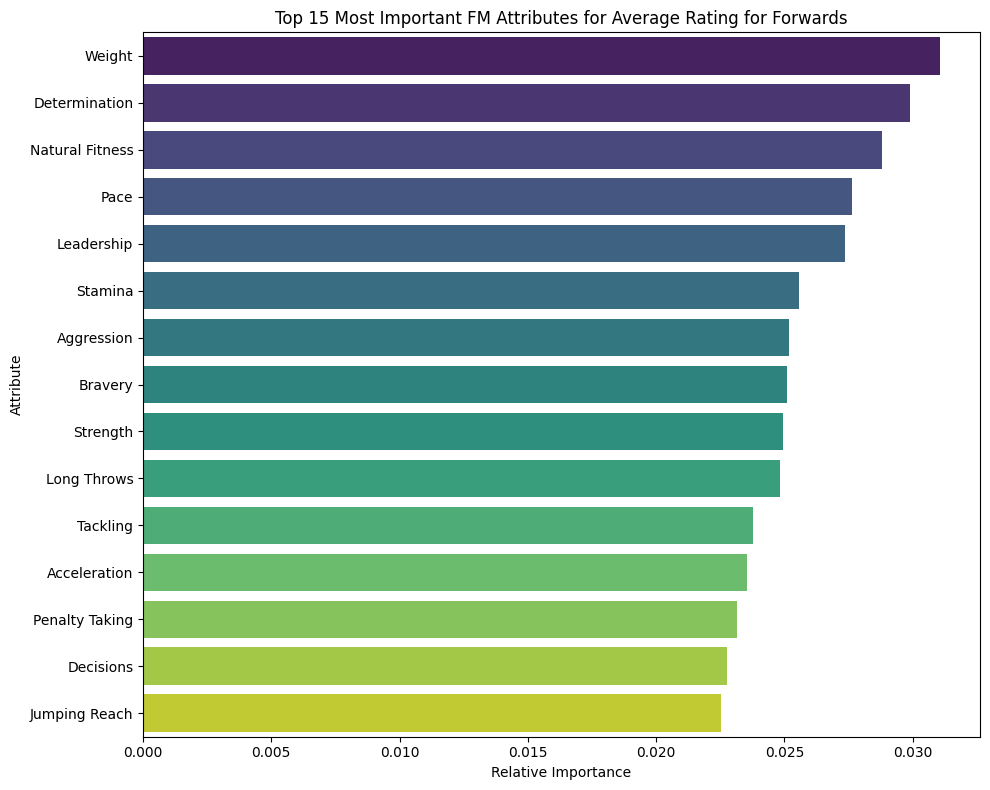

In [42]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the model 
# (random_state ensures you get the same results every time)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model on your scaled training data
# This step might take a minute depending on your dataset size
rf_model.fit(X_train, y_train)

# 3. Extract the feature importances
importances = rf_model.feature_importances_

# 4. Create a clean pandas DataFrame to view the results
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 5. Sort them from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Let's print the top 10 most important attributes
print(feature_importance_df.head(10))

# Plotting the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15), 
    palette='viridis'
)
plt.title('Top 15 Most Important FM Attributes for Average Rating for Forwards')
plt.xlabel('Relative Importance')
plt.ylabel('Attribute')
plt.tight_layout()
plt.show()

            Feature  Importance
48           Weight    0.031074
6     Determination    0.029895
32  Natural Fitness    0.028823
33             Pace    0.027634
8        Leadership    0.027379
34          Stamina    0.025558
0        Aggression    0.025200
2           Bravery    0.025090
35         Strength    0.024934
22      Long Throws    0.024820


C:\Users\admin\AppData\Local\Temp\ipykernel_13680\102338460.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


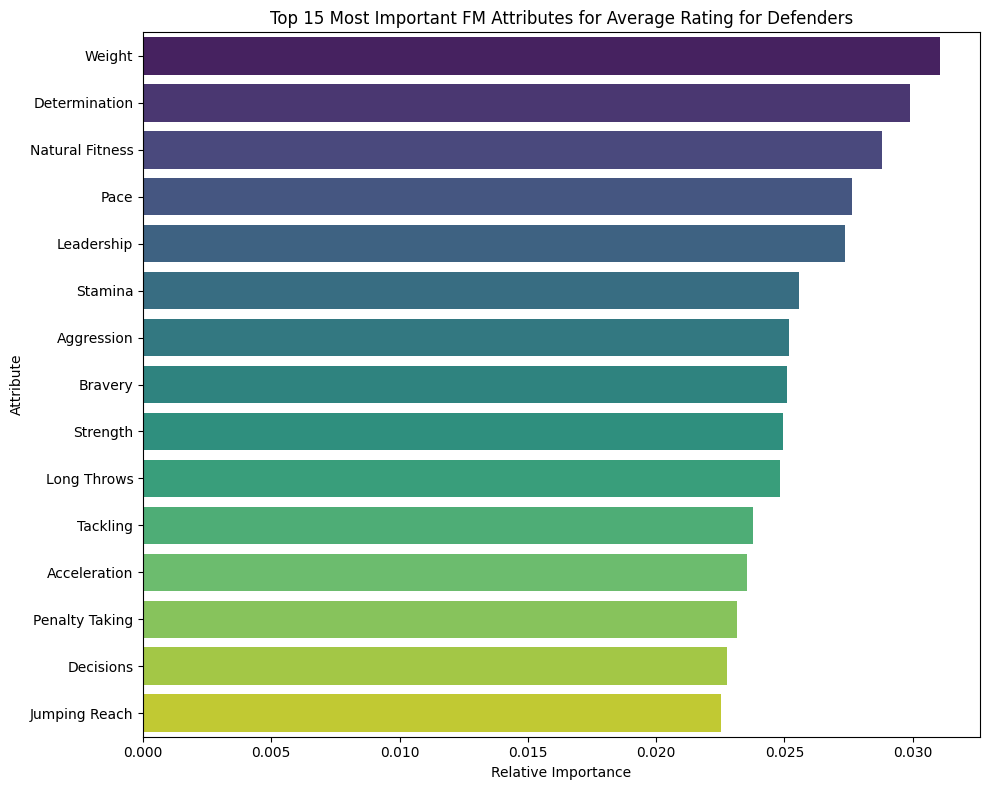

In [ ]:
# Set X and y
X = df_def[visible_features]
y = df_def['Av Rat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Initialize the model 
# (random_state ensures you get the same results every time)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model on your scaled training data
# This step might take a minute depending on your dataset size
rf_model.fit(X_train, y_train)

# 3. Extract the feature importances
importances = rf_model.feature_importances_

# 4. Create a clean pandas DataFrame to view the results
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 5. Sort them from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Let's print the top 10 most important attributes
print(feature_importance_df.head(10))

# Plotting the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15), 
    palette='viridis'
)
plt.title('Top 15 Most Important FM Attributes for Average Rating for Defenders')
plt.xlabel('Relative Importance')
plt.ylabel('Attribute')
plt.tight_layout()
plt.show()

            Feature  Importance
33             Pace    0.029474
6     Determination    0.028622
48           Weight    0.028198
8        Leadership    0.027720
30          Balance    0.025726
2           Bravery    0.025545
32  Natural Fitness    0.025528
26         Tackling    0.025108
34          Stamina    0.024818
0        Aggression    0.024291


C:\Users\admin\AppData\Local\Temp\ipykernel_13680\1415477779.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


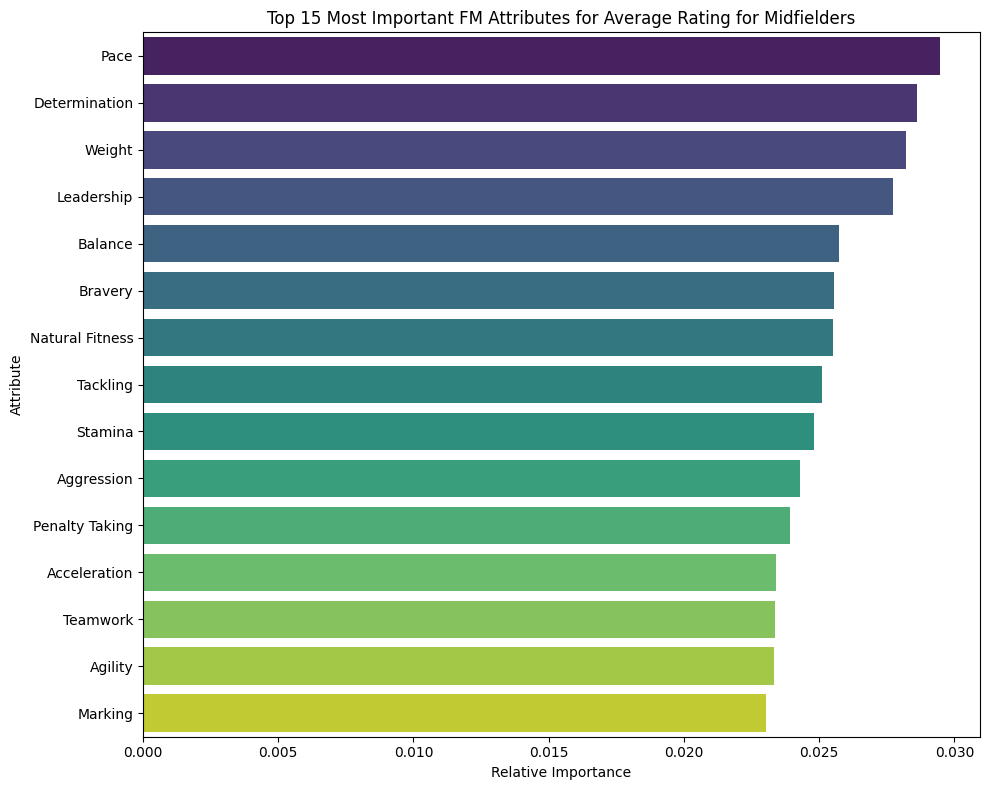

In [ ]:
# Set X and y
X = df_mid[visible_features]
y = df_mid['Av Rat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Initialize the model 
# (random_state ensures you get the same results every time)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model on your scaled training data
# This step might take a minute depending on your dataset size
rf_model.fit(X_train, y_train)

# 3. Extract the feature importances
importances = rf_model.feature_importances_

# 4. Create a clean pandas DataFrame to view the results
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 5. Sort them from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Let's print the top 10 most important attributes
print(feature_importance_df.head(10))

# Plotting the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15), 
    palette='viridis'
)
plt.title('Top 15 Most Important FM Attributes for Average Rating for Midfielders')
plt.xlabel('Relative Importance')
plt.ylabel('Attribute')
plt.tight_layout()
plt.show()

            Feature  Importance
46         Throwing    0.033943
44         Reflexes    0.032497
2           Bravery    0.030825
48           Weight    0.028761
6     Determination    0.028110
43         Punching    0.026541
38    Communication    0.026464
4     Concentration    0.026313
29          Agility    0.025662
37  Command of Area    0.025367


C:\Users\admin\AppData\Local\Temp\ipykernel_13680\3990645567.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


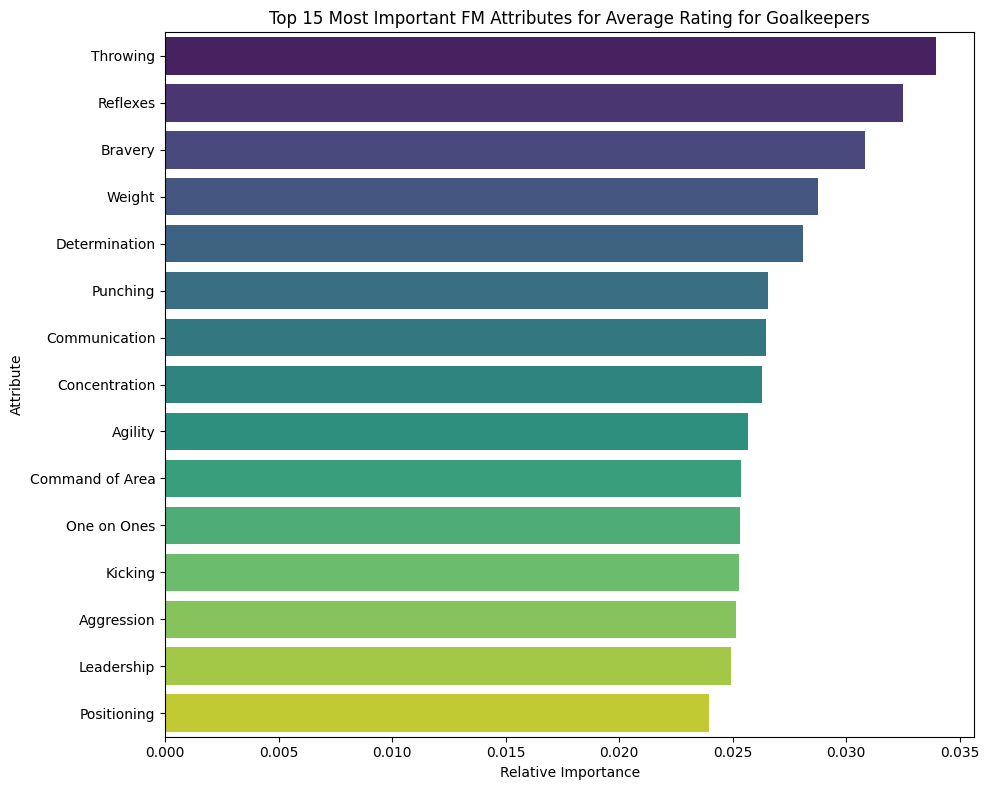

In [ ]:
# Set X and y
X = df_gk[visible_features]
y = df_gk['Av Rat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Initialize the model 
# (random_state ensures you get the same results every time)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model on your scaled training data
# This step might take a minute depending on your dataset size
rf_model.fit(X_train, y_train)

# 3. Extract the feature importances
importances = rf_model.feature_importances_

# 4. Create a clean pandas DataFrame to view the results
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 5. Sort them from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Let's print the top 10 most important attributes
print(feature_importance_df.head(10))

# Plotting the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15), 
    palette='viridis'
)
plt.title('Top 15 Most Important FM Attributes for Average Rating for Goalkeepers')
plt.xlabel('Relative Importance')
plt.ylabel('Attribute')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Make predictions on both the training and testing data
# (Assuming your model is named 'rf_model' from the previous step)
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 2. Calculate Mean Absolute Error (MAE)
# This tells you exactly how many points you are off by on average (e.g., off by 0.15 rating)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

# 3. Calculate R-squared (R2)
# This tells you the percentage of the variance in the data your model successfully explains (1.0 is perfect)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# 4. Print the results nicely
print("--- MODEL PERFORMANCE ('ACCURACY') ---")
print("\nTRAINING DATA:")
print(f"Mean Absolute Error: {mae_train:.4f} rating points")
print(f"R-squared Score:     {r2_train:.4f}")

print("\nTESTING DATA (The Real Test):")
print(f"Mean Absolute Error: {mae_test:.4f} rating points")
print(f"R-squared Score:     {r2_test:.4f}")

--- MODEL PERFORMANCE ('ACCURACY') ---

TRAINING DATA:
Mean Absolute Error: 0.0934 rating points
R-squared Score:     0.8581

TESTING DATA (The Real Test):
Mean Absolute Error: 0.2710 rating points
R-squared Score:     -0.0103


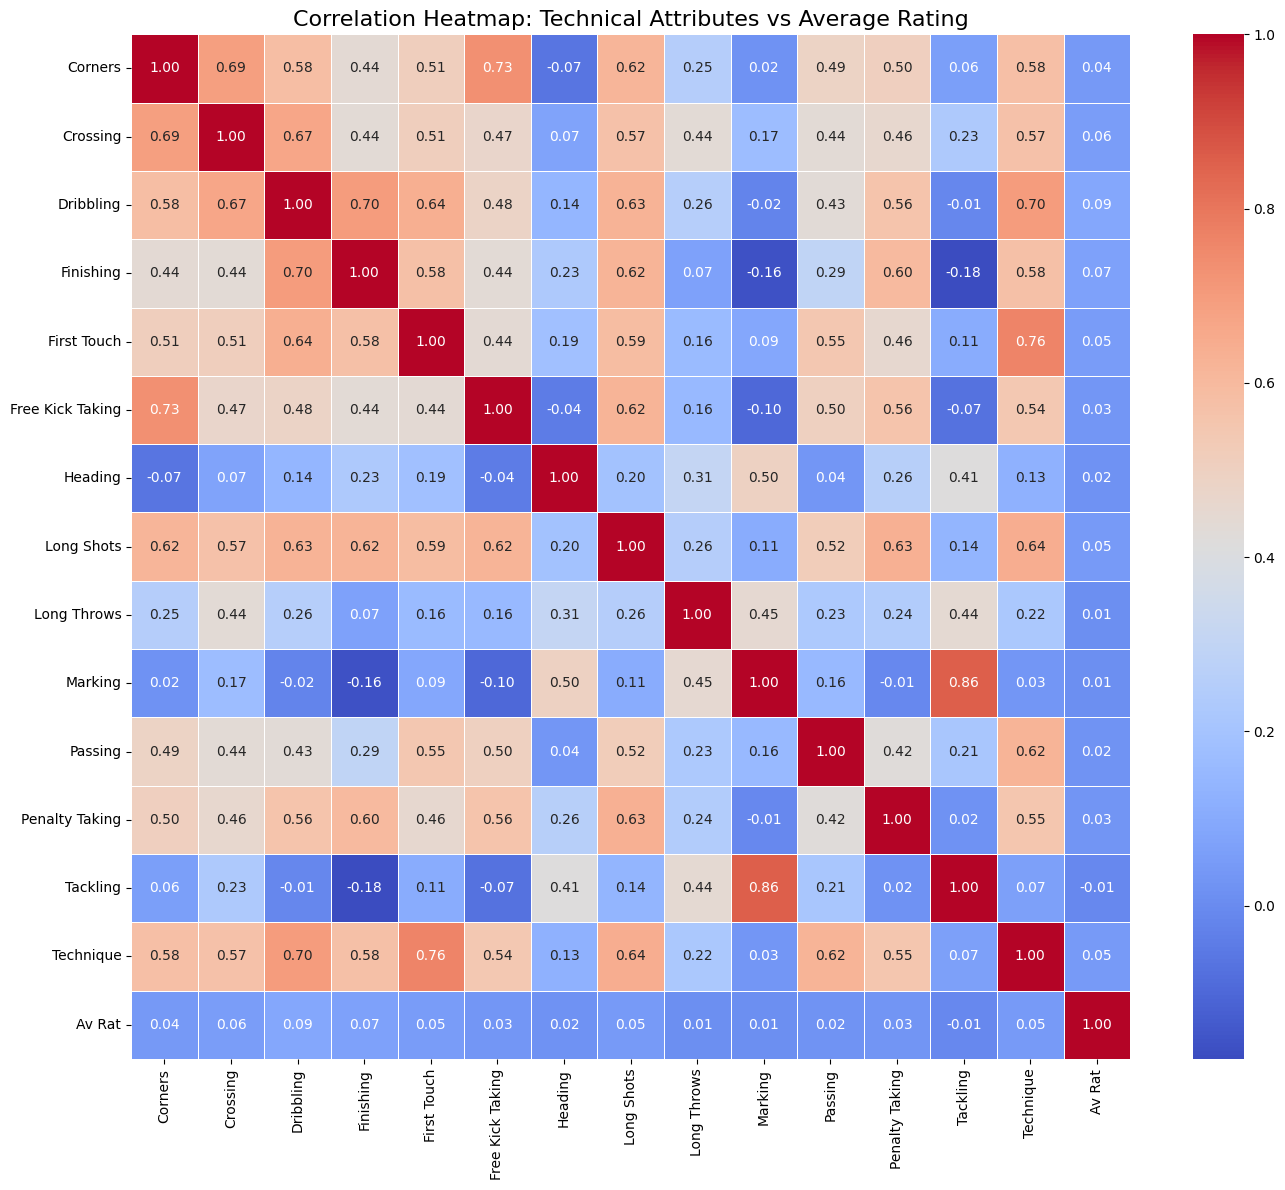

In [ ]:
plt.figure(figsize=(14, 12))



technical_features = ['Corners', 'Crossing', 'Dribbling', 'Finishing', 'First Touch', 
    'Free Kick Taking', 'Heading', 'Long Shots', 'Long Throws', 
    'Marking', 'Passing', 'Penalty Taking', 'Tackling', 'Technique', 'Av Rat']


# Calculate the correlation matrix
corr_matrix = df[technical_features].corr()

# Create a beautiful heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Prints the exact numbers inside the boxes
    cmap='coolwarm',     # Red = Positive correlation, Blue = Negative
    fmt='.2f',           # Rounds numbers to 2 decimal places
    linewidths=0.5
)

plt.title('Correlation Heatmap: Technical Attributes vs Average Rating', fontsize=16)
plt.tight_layout()
plt.show()

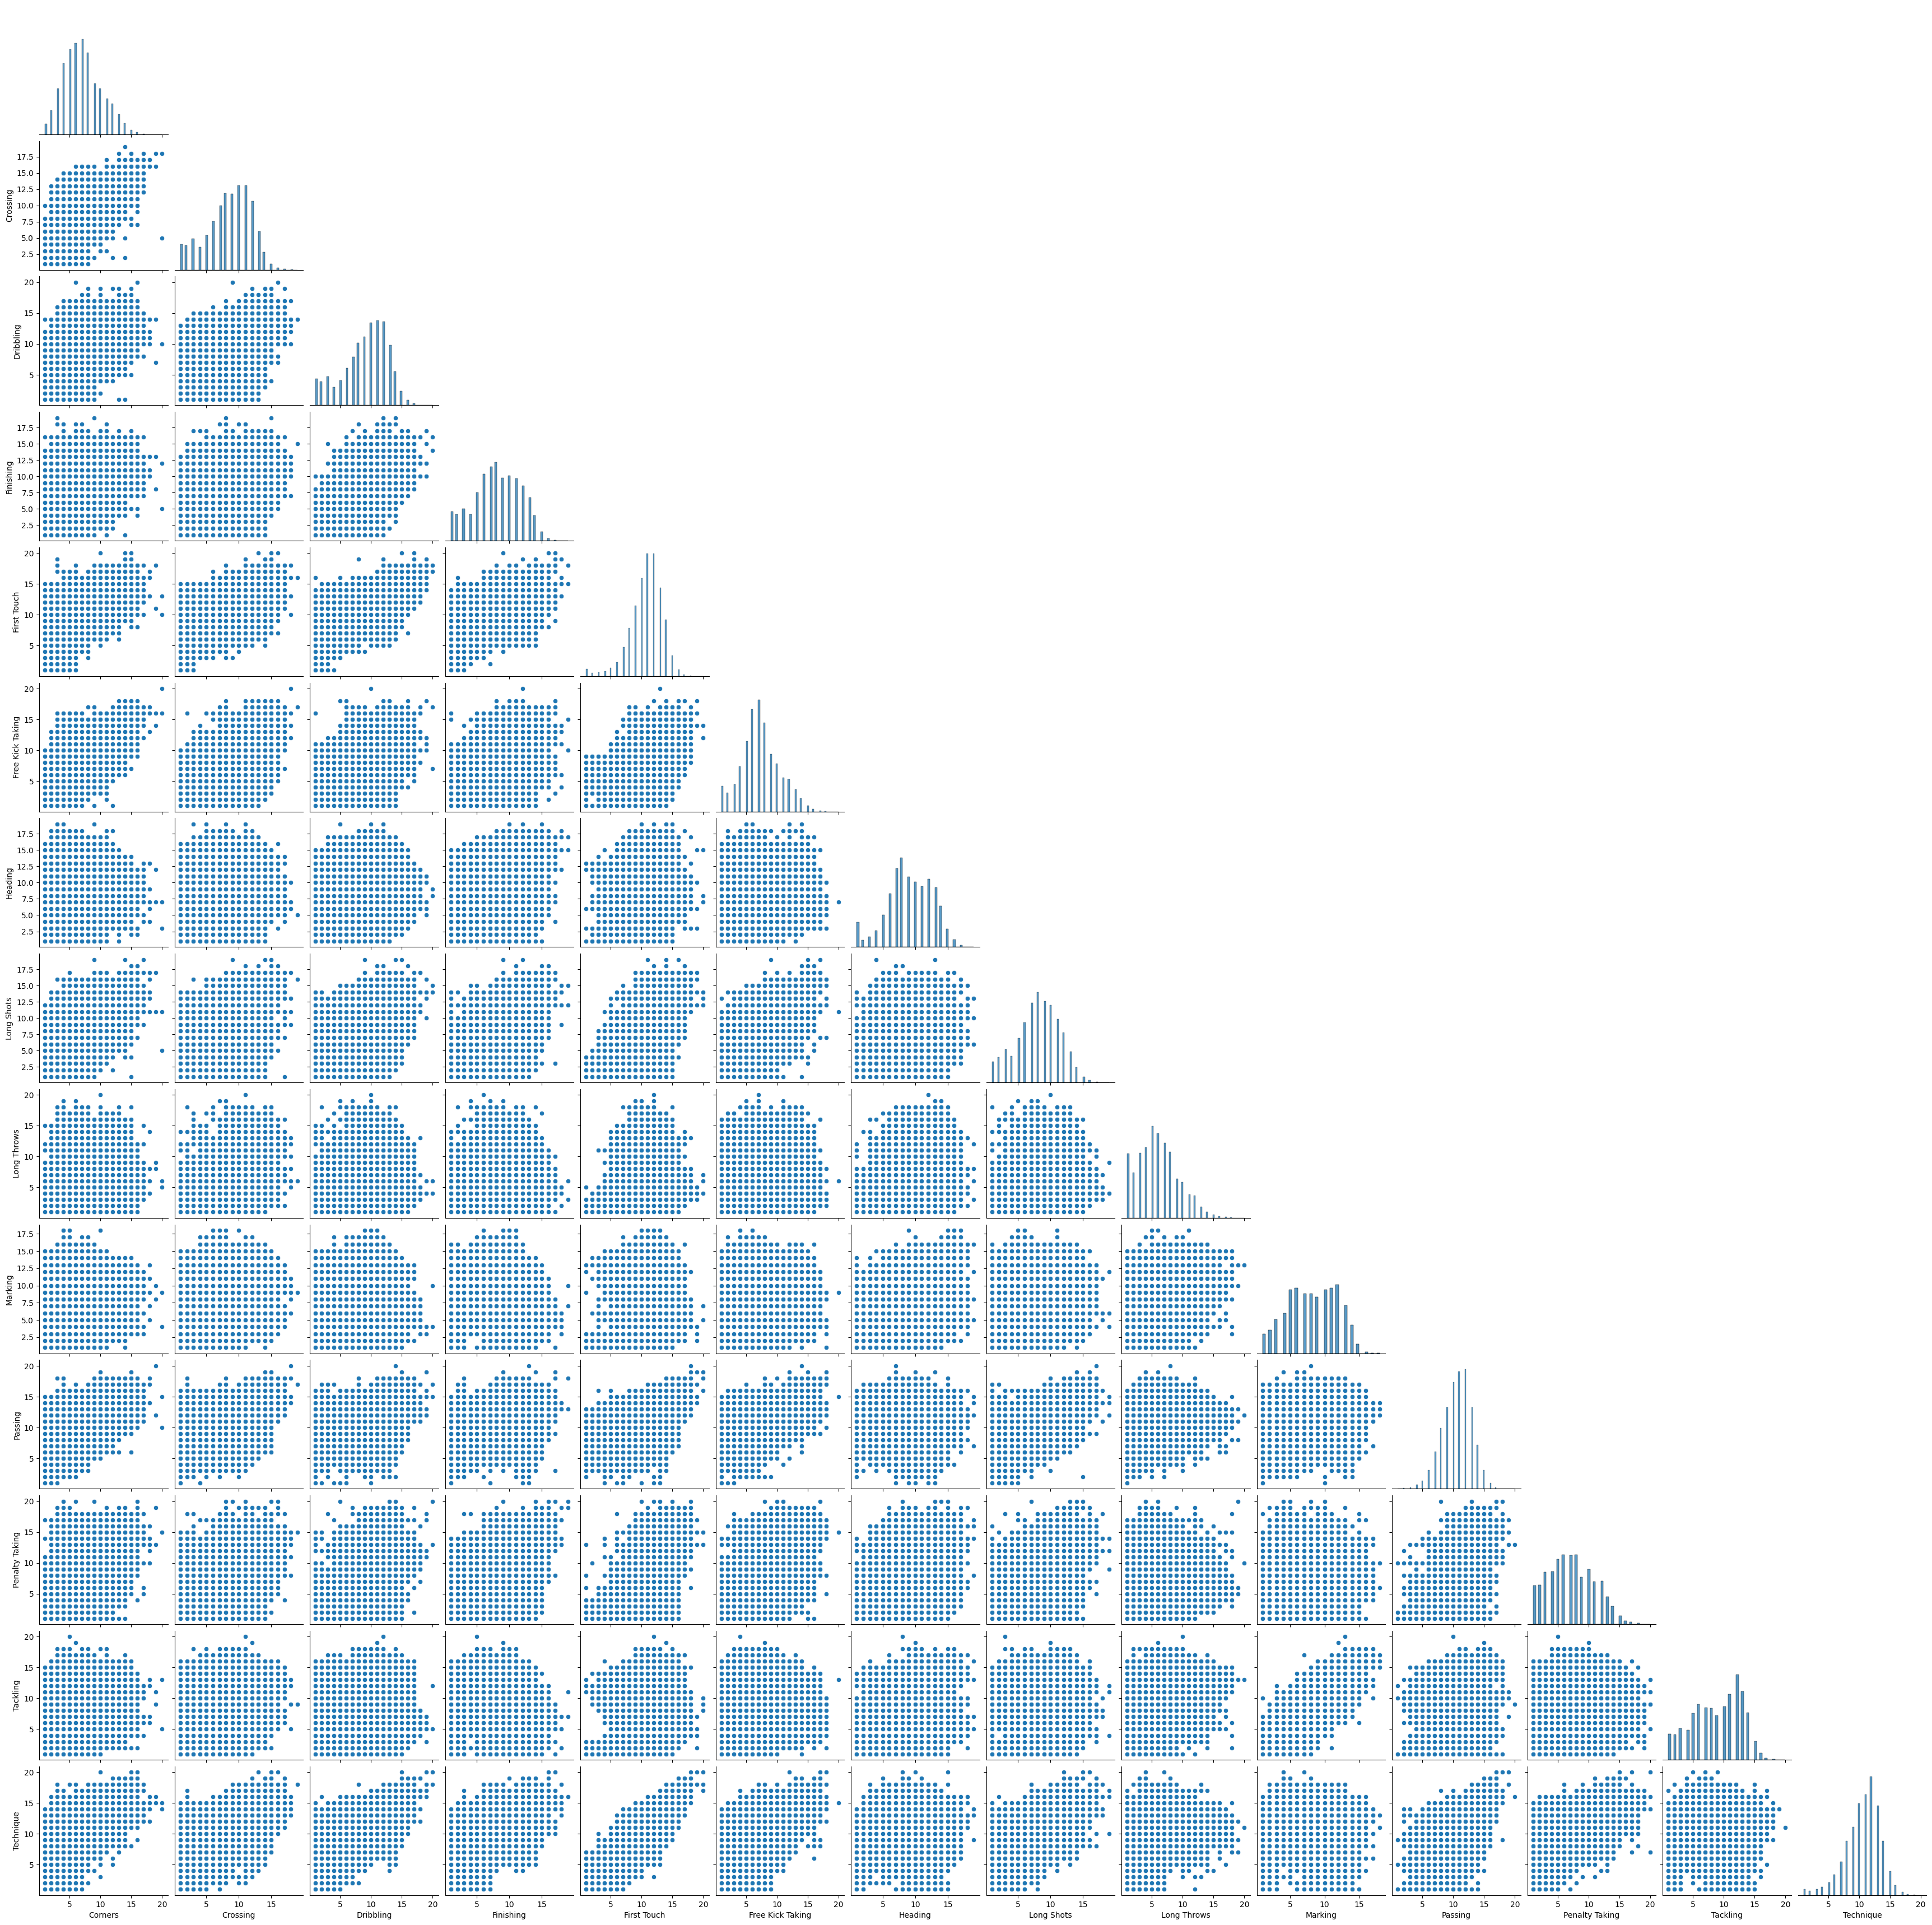

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

technical_features = [
    'Corners', 'Crossing', 'Dribbling', 'Finishing', 'First Touch', 
    'Free Kick Taking', 'Heading', 'Long Shots', 'Long Throws', 
    'Marking', 'Passing', 'Penalty Taking', 'Tackling', 'Technique',
    'Av Rat'  # Adding the target variable
]

# Create the pairplot
# Note: corner=True removes the duplicate charts on the top half of the grid
sns.pairplot(df[technical_features], corner=True)

# Save it to a file so you can open it separately and zoom in
plt.savefig('technical_attributes_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Filter the features
# We want to remove the boolean/categorical 'Foot' columns because 
# scatter plots don't look good with 0s and 1s. We just want the 1-20 stats and physicals.
features_to_plot = [f for f in visible_features if f not in [
    'Left Foot', 'Right Foot', 'Preferred Foot_Left', 
    'Preferred Foot_Left Only', 'Preferred Foot_Right', 
    'Preferred Foot_Right Only'
]]

# 2. Set up the grid size
n_features = len(features_to_plot)
cols = 4  # Let's make it 4 columns wide
rows = math.ceil(n_features / cols) # Calculate how many rows we need

# 3. Create the massive figure
# We make it 20 inches wide, and dynamically adjust the height based on the number of rows
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
fig.suptitle('Striker Attributes vs Average Rating', fontsize=24, y=1.01)

# Flatten the axes array so we can easily loop through it
axes = axes.flatten()

# 4. Loop through every feature and create a scatter plot
for i, feature in enumerate(features_to_plot):
    sns.scatterplot(
        x=feature, 
        y='Av Rat', 
        data=df_for_cleaned, # Make sure to use your cleaned Striker dataframe!
        ax=axes[i], 
        alpha=0.4,           # Adds transparency to see overlapping points
        color='royalblue'
    )
    
    axes[i].set_title(f'{feature} vs Av Rat', fontsize=14)
    axes[i].set_ylabel('Av Rat')
    axes[i].set_xlabel(feature)

# 5. Clean up the grid
# If we have an odd number of features, we might have empty charts at the bottom right. This deletes them.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing so labels don't overlap
plt.tight_layout()

# 6. Save and show!
# Saving it is crucial because it will be too big to comfortably read inside a notebook cell
plt.savefig('striker_scatterplots.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'visible_features' is not defined